In [1]:
from alc import *

In [2]:
actualPath = os.getcwd()
basePath = os.path.join(actualPath, "cats_and_dogs")
Xt, Yt, Xv, Yv = cargarDataset(basePath)

## Análisis

### Matriz de confusión de métodos

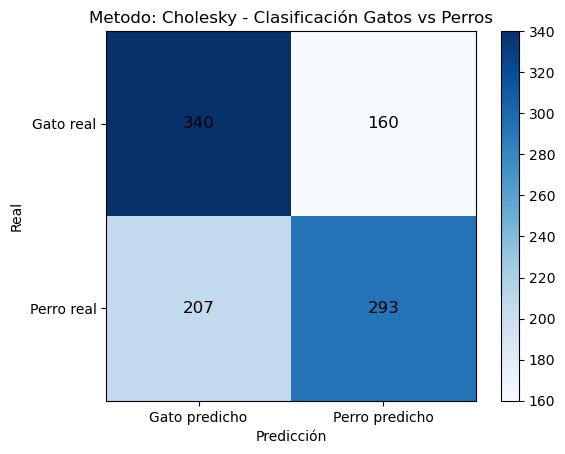

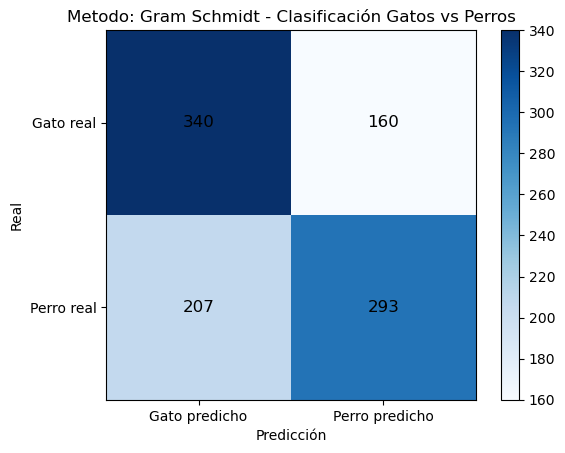

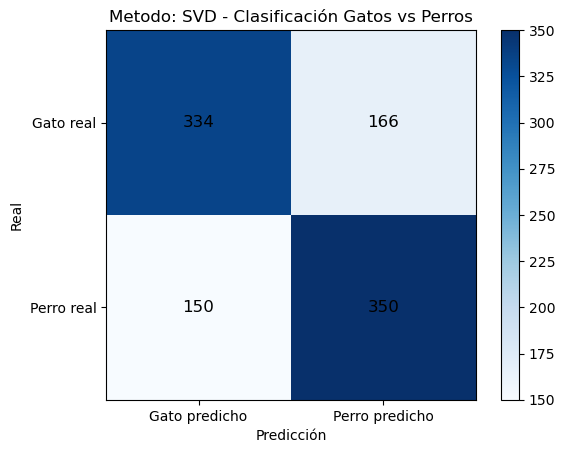

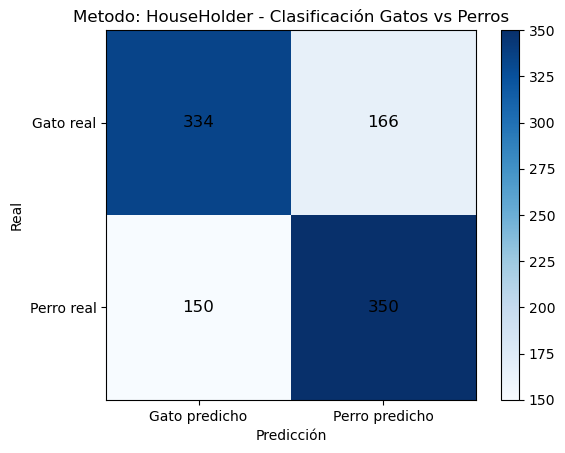

In [3]:
nombres_metodos = ["Cholesky","Gram Schmidt","SVD","HouseHolder"]


W_SVD = np.load("W/W_svd.npy")
W_CHOLESKY = np.load("W/W_e_primitivas.npy")
W_GS = np.load("W/W_gramschmidt.npy")
W_HH = np.load("W/W_householder.npy")
        
r_SVD = lb1.transpuesta( W_SVD @ Xv)
r_CHOLESKY = lb1.transpuesta( W_CHOLESKY @ Xv)
r_HH = lb1.transpuesta( W_HH @ Xv)
r_GS = lb1.transpuesta( W_GS @ Xv)


lista_r = list()
lista_r.append(r_CHOLESKY)
lista_r.append(r_GS)
lista_r.append(r_SVD)
lista_r.append(r_HH)



aciertoGatos = list()
aciertoPerros = list()
precisionModelo = list()



for r in lista_r:
    predicciones = np.argmax(r, axis=1)
    etiquetas_reales = np.argmax(Yv, axis=1)

    
    matriz_conf = confusion_matrix(etiquetas_reales, predicciones)

 
    aciertoGatos.append(matriz_conf[0,0]/5) 
    aciertoPerros.append(matriz_conf[1,1]/5)
    precisionModelo.append((matriz_conf[0,0] + matriz_conf[1,1])/10)


    plt.imshow(matriz_conf, cmap='Blues')
    plt.colorbar()

    for i in range(matriz_conf.shape[0]):
        for j in range(matriz_conf.shape[1]):
            plt.text(j, i, matriz_conf[i, j],
                     ha='center', va='center', color='black', fontsize=12)


    plt.xticks([0, 1], ['Gato predicho', 'Perro predicho'])
    plt.yticks([0, 1], ['Gato real', 'Perro real'])

    plt.xlabel('Predicción')
    plt.ylabel('Real')

    metodo = nombres_metodos.pop(0)  

    plt.title(f"Método: {metodo} - Clasificación Gatos vs Perros")
    plt.show()


### Tabla comparativa de resultados de cada metodología

In [4]:
data = {
    "Tasa de aciertos (gatos)": [f"{x} %" for x in aciertoGatos],
    "Tasa de aciertos (perros)": [f"{x} %" for x in aciertoPerros],
    "Acierto total": [f"{x} %" for x in precisionModelo]
}

metodos = [
    "Cholesky",
    "Gram Schmidt",
    "SVD",
    "HouseHolder"
]

df = pd.DataFrame(data, index=metodos)

print("\n=== Comparación de Métodos ===\n")
print(df.to_string())


=== Comparación de Métodos ===

             Tasa de aciertos (gatos) Tasa de aciertos (perros) Acierto total
Cholesky                       68.0 %                    58.6 %        63.3 %
Gram Schmidt                   68.0 %                    58.6 %        63.3 %
SVD                            66.8 %                    70.0 %        68.4 %
HouseHolder                    66.8 %                    70.0 %        68.4 %


## Síntesis Final

Una vez finalizadas nuestras experimentaciones, analizamos cuáles metodologías son las más adecuadas usando como parámetros de evaluación: la complejidad, la precisión de aciertos y el equilibrio de las predicciones.
## Resultados
Con el método de Cholesky, los gatos bien asignados fueron el 68%, los perros el 58,6%, y el acierto total fue de 63,3%. En este método hay una diferencia llamativa entre los aciertos de gatos y perros, teniendo una tendencia a pronosticar gatos. Suponemos que la alta tasa de aciertos sobre gatos se debe a esta tendencia.
Para el método de Gram-Schmidt, se puede ver que los resultados en la predicción son exactamente iguales a los del anterior, y si miramos las matrices de confusión veremos que ambas son idénticas.
El método de SVD obtuvo una tasa de aciertos de gatos del 66,8%, de perros del 70% y una precisión total de 68,4%. Se puede observar que la tasa de aciertos entre ambos es similar. Esto es una buena señal, ya que nos muestra una matriz de confusión que conserva equilibrio en los resultados, es decir, no existen sesgos hacia alguna de las dos clases.
Por último, con respecto a HouseHolder, obtuvimos una tasa de acierto del 66,8% en gatos, de 70% en perros y un 68,4% total. Nuevamente obtuvimos matrices de confusión iguales entre dos métodos, en este caso el método SVD y el de HouseHolder.
## Análisis de complejidad
Todos los métodos tienen una complejidad O(n³), sin embargo, el método de Cholesky resultó ser el mas rápido; creemos que esto se debe a que la constante es mucho más chica que en los demás. Luego le siguen los métodos por QR, y por último el método más pesado es el de SVD, probablemente por tener una mayor cantidad de operaciones que los otros dos.
## Conclusión
Nuestra conclusión es que el modelo entrenado con el método de HouseHolder es el mejor. Este método muestra un balance entre efectividad y equilibrio de resultados. Sin embargo, es más costoso que el de Cholesky, por lo que en una situación donde el costo sea relevante puede ser mejor el método de Cholesky.
Los "peores métodos" terminaron siendo el SVD y el de Gram Schmidt, no por malos resultados sino porque hay otros más baratos con la misma efectividad.
Entonces, en un escenario donde el costo no sea algo a tener en cuenta, el mejor método es el de HouseHolder, mientras que si el costo es importante, Cholesky podría ser la mejor opción.